In [1]:
import os
import urllib.request
import pandas as pd

def download_seeds_dataset():
    # 数据集URL
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
    
    # 本地保存路径
    data_dir = "data"
    file_path = os.path.join(data_dir, "seeds_dataset.csv")
    
    # 创建data目录（如果不存在）
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
        print(f"创建目录: {data_dir}")
    
    try:
        # 下载数据集
        print("开始下载UCI种子数据集...")
        with urllib.request.urlopen(url) as response:
            # 读取数据
            data = response.read().decode('utf-8')
            
            # 处理数据格式（将多个空格替换为逗号）
            formatted_data = []
            for line in data.strip().split('\n'):
                # 去除行首尾空格并将多个空格替换为单个逗号
                cleaned_line = ','.join(line.strip().split())
                formatted_data.append(cleaned_line)
            
            # 组合成CSV格式
            csv_data = '\n'.join(formatted_data)
            
            # 保存到文件
            with open(file_path, 'w') as f:
                f.write(csv_data)
            
            print(f"数据集已成功保存到: {file_path}")
            
            # 读取并返回数据集信息
            df = pd.read_csv(file_path, header=None)
            print(f"数据集包含 {df.shape[0]} 个样本和 {df.shape[1]} 个特征")
            return "

开始下载UCI种子数据集...
数据集已成功保存到: data\seeds_dataset.csv
数据集包含 210 个样本和 8 个特征


# 1.读取数据

In [5]:
data

,0
0,"15.26,14.84,0.871,5.763,3.312,2.221,5.22,1"
1,"14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1"
2,"14.29,14.09,0.905,5.291,3.337,2.699,4.825,1"
3,"13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1"
4,"16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1"
...,...
205,"12.19,13.2,0.8783,5.137,2.981,3.631,4.87,3"
206,"11.23,12.88,0.8511,5.14,2.795,4.325,5.003,3"
207,"13.2,13.66,0.8883,5.236,3.232,8.315,5.056,3"
208,"11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3"


In [8]:
import pandas as pd
# 读取数据，用正则表达式匹配逗号作为分隔符
data = pd.read_csv('./data/seeds_dataset.csv', sep=',', header=None)
# 给每一列命名（共8列：7个特征 + 1个类别）
data.columns = ['A', 'P', 'C', 'LK', 'WK', 'AC', 'LKG', 'class']
# 查看前5行，确认列是否拆分成功
print(data.head())

       A      P       C     LK     WK     AC    LKG  class
0  15.26  14.84  0.8710  5.763  3.312  2.221  5.220      1
1  14.88  14.57  0.8811  5.554  3.333  1.018  4.956      1
2  14.29  14.09  0.9050  5.291  3.337  2.699  4.825      1
3  13.84  13.94  0.8955  5.324  3.379  2.259  4.805      1
4  16.14  14.99  0.9034  5.658  3.562  1.355  5.175      1


# 2.观察特征数据的分布与区分度

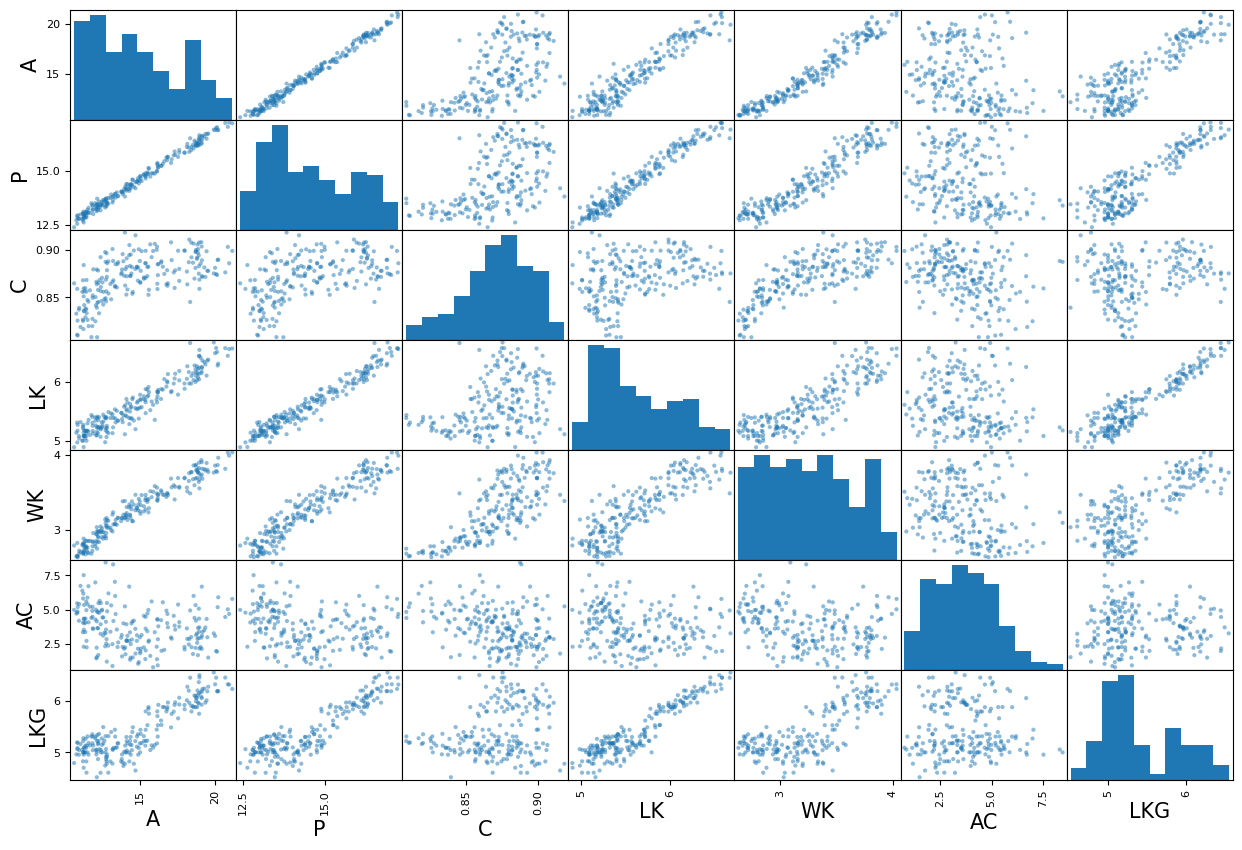

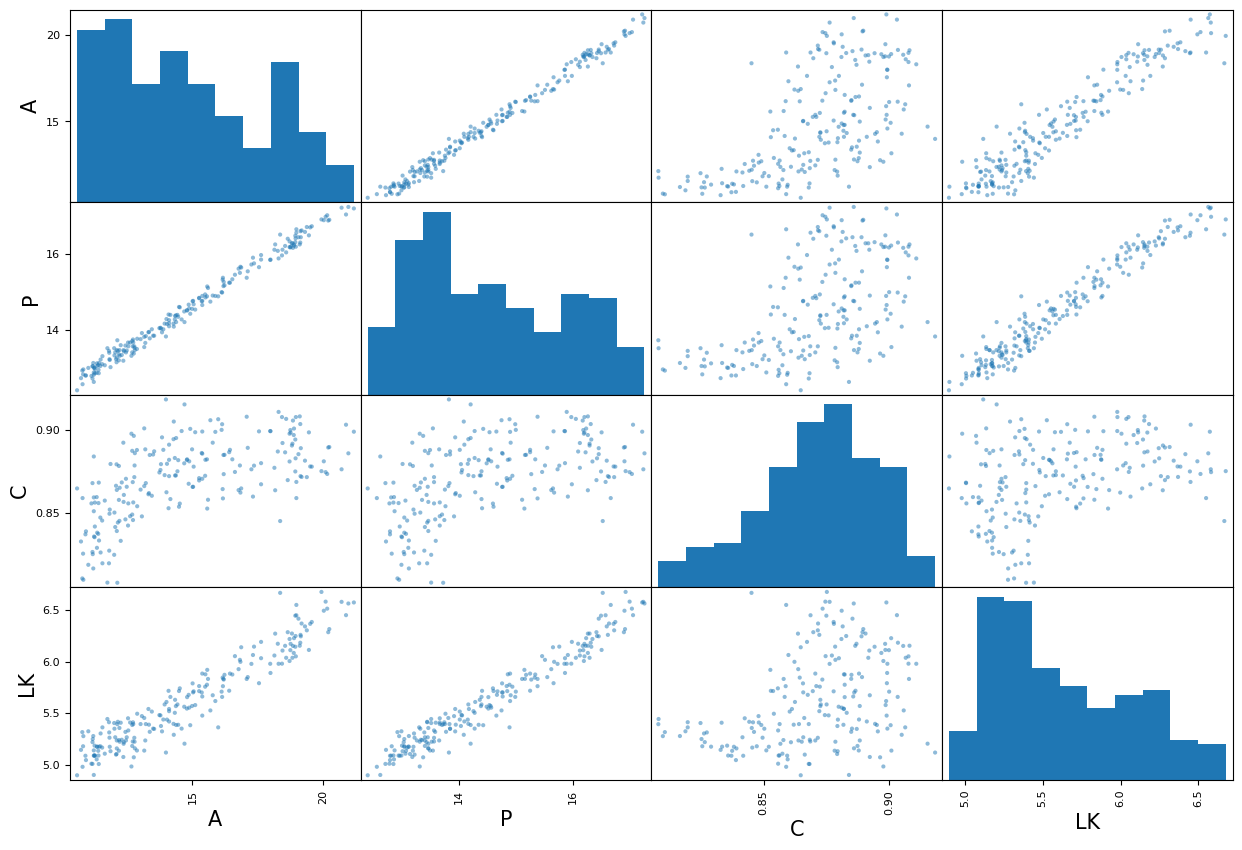

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (15,10)
plt.rcParams.update({'font.size':15})
pd.plotting.scatter_matrix(data.iloc[:,:7],diagonal='hist')
pd.plotting.scatter_matrix(data.iloc[:,:4],diagonal='hist')
plt.show()

# 3.数据处理

In [14]:
#获取数据
x = data.iloc[:,:7].values.astype(float)
#使用StandardScaler()类对数据进行预处理
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)# 获取数据（取前7列特征）
x = data.iloc[:, :7].values.astype(float)

# 使用StandardScaler对数据进行标准化预处理
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaler.fit(x)  # 计算均值和标准差，用于后续标准化
x_scaled = scaler.transform(x)  # 应用标准化转换

# 查看标准化后的前5行数据
print("标准化后的前5行数据：")
print(x_scaled[:5])

标准化后的前5行数据：
[[ 1.42097769e-01  2.15462437e-01  6.06017918e-05  3.04218199e-01
   1.41701823e-01 -9.86151745e-01 -3.83577423e-01]
 [ 1.11880257e-02  8.22375713e-03  4.28515270e-01 -1.68624664e-01
   1.97432229e-01 -1.78816620e+00 -9.22013487e-01]
 [-1.92066576e-01 -3.60200562e-01  1.44238325e+00 -7.63637453e-01
   2.08047544e-01 -6.67479334e-01 -1.18919199e+00]
 [-3.47091272e-01 -4.75333162e-01  1.03938133e+00 -6.88978054e-01
   3.19508356e-01 -9.60817955e-01 -1.22998260e+00]
 [ 4.45257175e-01  3.30595037e-01  1.37450924e+00  6.66655647e-02
   8.05159035e-01 -1.56349549e+00 -4.75356297e-01]]


# 4.用K-均值聚类算法训练模型

In [15]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=1)
kmeans.fit(x_scaled)

D:\anaconda\envs\financial-ml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=1)

# 5.输出聚类结果,绘制散点图

[2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 2 1 2 2 2 2 2 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 0 0 2 0 2 2 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 1 1 1 1 1 1 1 1]


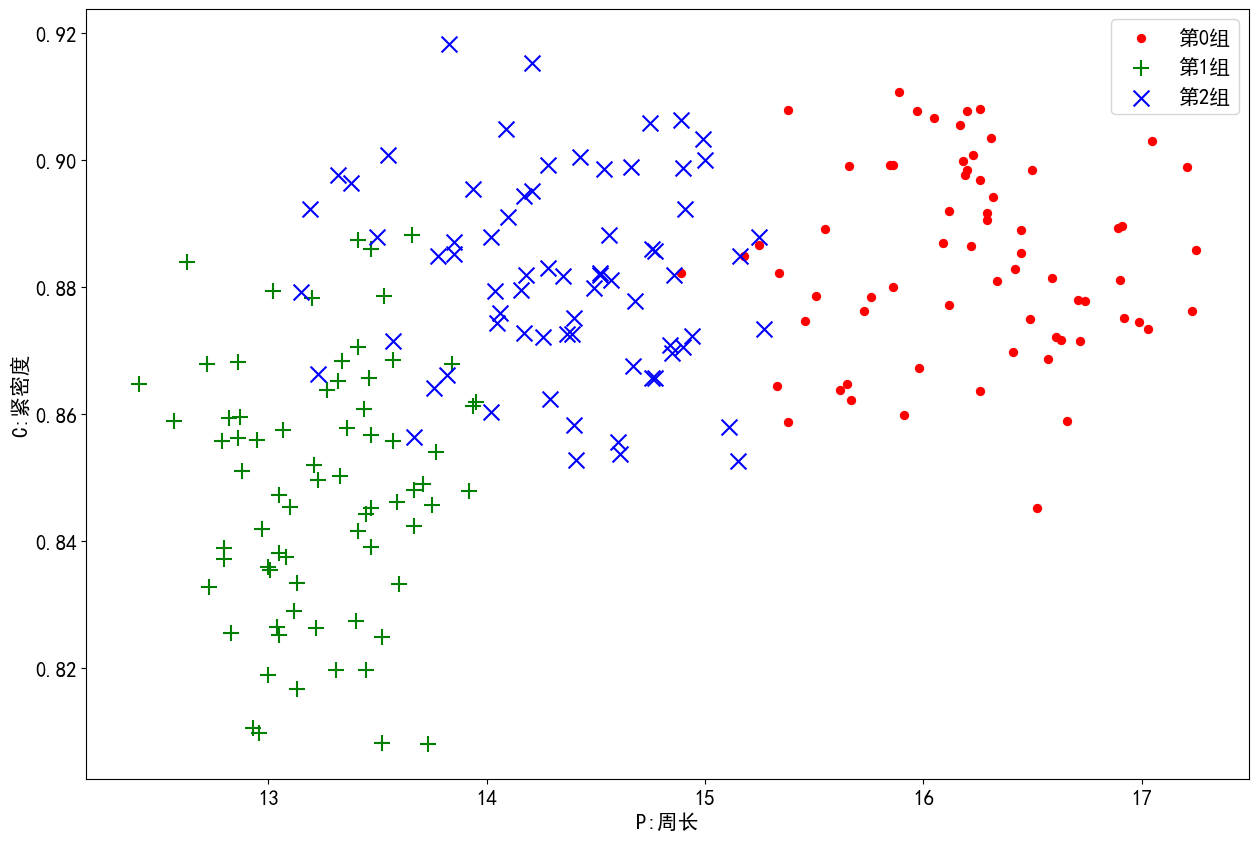

In [17]:
import numpy as np
import matplotlib.pyplot as plt
print(kmeans.labels_)
plt.rcParams['font.sans-serif'] = ['SimHei']
markers = ('.','+','x')
C = ('r','g','b')
#以P与C为横纵坐标为例,绘制各点所属的组分布
for i in np.unique(kmeans.labels_):
    plt.scatter(data[kmeans.labels_ == i].iloc[:,1:2],
                data[kmeans.labels_ == i].iloc[:,2:3],
                c = C[i],marker = markers[i],s=130,label=f'第{i}组')
plt.legend()
plt.xlabel('P:周长')
plt.ylabel('C:紧密度')
plt.show()